# Source A — the whole arc, §1 → §24

Source A is the Wikipedia-county-articles pillar of `E_macro`, a six-pillar
county dataset. This notebook is the map of everything the experiment line
found, in one pass: what was tried, what happened to it, and where it stands.
The three round notebooks in this directory —
`source_a_extraction_round.ipynb`, `source_a_structure_round.ipynb`,
`source_a_shape_profile_round.ipynb` — remain the deep dives. The full register
is `source-a-findings.md`, and every section number below (§n) points into it.

## The one thing to take away

**Nearly every Source A win has shrunk or vanished once a better control was
added.** Not once, as an accident — four times, in four different rounds, each
time because a control that cost almost nothing to add had been left out:

| round | the win, as first measured | the control that was missing | what was left |
|---|---|---|---|
| §17 | typed block vs a size-plus-state baseline | the other five pillars | under a third of it |
| §22.2 | the selected embedding arm's marginal contribution | two latitude/longitude columns | approximately nothing |
| §23.3 | article shape vs a *linear-in-logs* size baseline | curvature in that same size | roughly a quarter, and an information-free block outscored it several times over |
| §24.2 | — | — | article shape rebuilds `log_population` on its own at two-thirds R² |

Every number behind that table is printed by a cell below, and the ledger in
Part six restates it from the artifacts directly.

**The other thing, which is equally true.** Source A ships 29 typed columns in
the feature matrix today, and §17 is the reason: against a baseline that already
holds county size, state, and every other pillar, those columns retain a small
but statistically real contribution, on the best-powered test in the whole
register. The pillar is not worthless. It is worth much less than any single
headline in this file suggested at the time that headline was written.

## How to read the numbers

Three conventions from the register are binding here and are repeated wherever
they apply, because quoting one side alone is how this line's mistakes happened:

- **A lift is meaningless without the baseline that produced it.** "Lift" in
  §13–§17 means over county size plus state, or over that plus every other
  pillar — two very different denominators. In §23–§24 it means over a
  *linear-in-logs* size baseline, or over a curvature-augmented one.
- **A null control is a unit, not an appendix.** From §23 onward every lift is
  reported beside what an information-free block scores through the identical
  protocol.
- **Where a basket has two honest denominators, both are shown.** The
  curvature-augmented baseline degrades on 6 of the 28 targets, so the all-28
  and undegraded-22 readings are quoted together and neither alone; they
  disagree on significance for the shipped block.

One further caveat travels with every basket-wide mean in this file: the
28-target cross-pillar basket is 20 QCEW location quotients out of 28, so no
aggregate here is a breadth claim. Per-pillar breakouts accompany the
aggregates for that reason.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image
from scipy.stats import wilcoxon

REPO = Path.cwd()
while not (REPO / "data").exists() and REPO != REPO.parent:
    REPO = REPO.parent
DATA, ANALYSIS, OUTPUTS = REPO / "data", REPO / "analysis-output", REPO / "outputs"
SOURCE_A = ANALYSIS / "source-a"
FIGURES = SOURCE_A / "figures"

mpl.rcParams.update({"figure.figsize": (11, 5.5), "figure.dpi": 110, "axes.grid": True,
                     "axes.axisbelow": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})


def load(name):
    return json.loads((SOURCE_A / name).read_text())


embed_stats = load("stats.json")                                    # §1-§12
extract_stats = load("source_a_extraction_stats.json")              # §13.2
tier_stats = load("source_a_tier_stats.json")                       # §13.1
rep_stats = load("source_a_representation_stats.json")              # §13.3, §14.2
marg_stats = load("source_a_marginal_stats.json")                   # §17
tiered_stats = load("source_a_tiered_embedding_stats.json")         # §20
repmarg_stats = load("source_a_representation_marginal_stats.json")  # §21, §22
struct_stats = load("source_a_structure_stats.json")                # §23
shape_stats = load("source_a_shape_profile_stats_scoring.json")     # §24

repmarg = pd.read_csv(OUTPUTS / "source_a_representation_marginal.csv",
                      float_precision="round_trip")
marg_by_pillar = pd.read_csv(OUTPUTS / "source_a_marginal_by_pillar.csv")
rep_by_pillar = pd.read_csv(OUTPUTS / "source_a_representation_by_pillar.csv")
struct_by_pillar = pd.read_csv(OUTPUTS / "source_a_structure_by_pillar.csv")

print(f"corpus: {extract_stats['n_counties']:,} counties, "
      f"{extract_stats['n_features']} typed columns from the lead "
      f"(§14 added the economy-section columns; "
      f"{struct_stats['n_typed_features']} ship)")
print(f"cross-pillar basket (§13-§24): {rep_stats['n_targets']} targets, "
      f"{rep_stats['n_folds']} folds, seed {rep_stats['random_seed']}")
print(f"external ACS basket (§21-§22): {repmarg_stats['n_targets']} targets, "
      f"{len(repmarg_stats['excluded_targets'])} excluded as degenerate (§22.1)")
print()
print("cross-pillar basket composition -- 20 of 28 are one QCEW table, so no")
print("aggregate below is a breadth claim:")
print(rep_by_pillar[["pillar", "n_targets"]].to_string(index=False))

corpus: 3,144 counties, 20 typed columns from the lead (§14 added the economy-section columns; 29 ship)
cross-pillar basket (§13-§24): 28 targets, 5 folds, seed 42
external ACS basket (§21-§22): 42 targets, 1 excluded as degenerate (§22.1)

cross-pillar basket composition -- 20 of 28 are one QCEW table, so no
aggregate below is a breadth claim:
pillar  n_targets
     B         20
     C          3
     D          3
     E          1
     F          1


## Part one — the embedding era (§1–§12)

Source A began as a 1024-dimensional `bge-m3` embedding of each county's
Wikipedia intro text, LLM-de-boilerplated with `gemma2:9b` (§12, adopted). The
unsupervised diagnostics were run against **geographic** distance, which is the
yardstick this project later rejected for this pillar, and they came back weak:
a Mantel permutation test found a real but small negative association between
geographic distance and embedding similarity, k-means silhouette peaked at a
value far under the ~0.25 usually treated as meaningful structure, and PC1
explained a low-single-digit share of variance. The one clean thematic read of
PC1 (§3.2) was a Wikipedia editorial artifact — Texas founding-and-namesake
narrative against near-stub demographic text — not the economic-transition
narrative the proposal expected (§10).

The cell below prints those diagnostics from the committed `stats.json`.

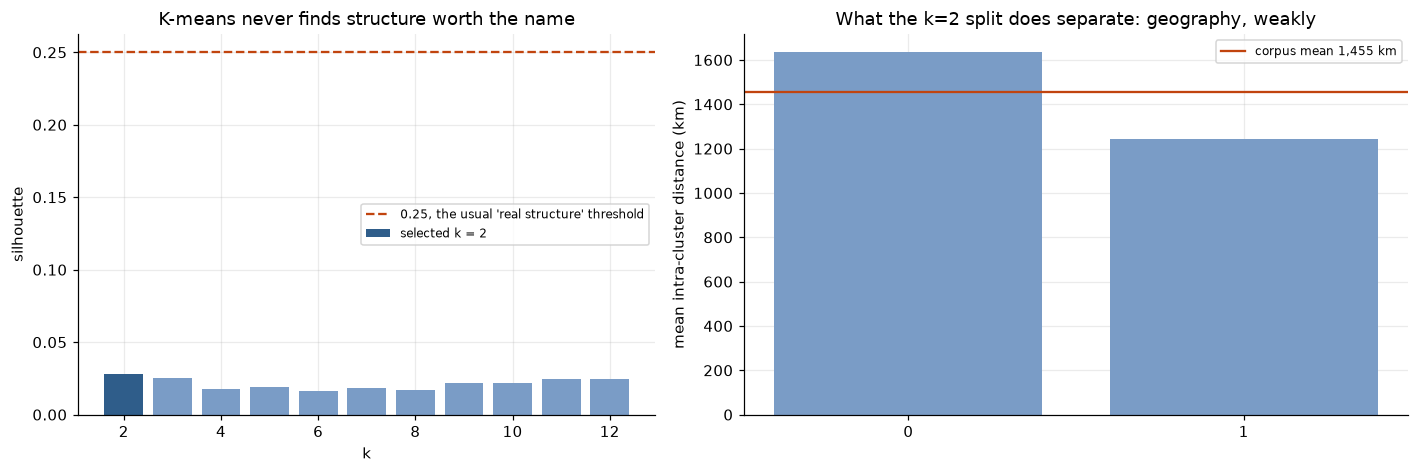

Mantel r = -0.2362, p = 0.0020 (499 permutations, seed 42, n = 2,849)
  -- against GEOGRAPHIC distance. Negative: nearby counties are very
     slightly more textually similar. This is not an economic yardstick,
     and §13 onward stops using it.
PC1 explains 3.938% of variance (n = 3,144); its theme is a Texas
     founding-narrative editorial artifact (§3.2), not economic content.
best silhouette across all k tried: 0.0284 at k = 2


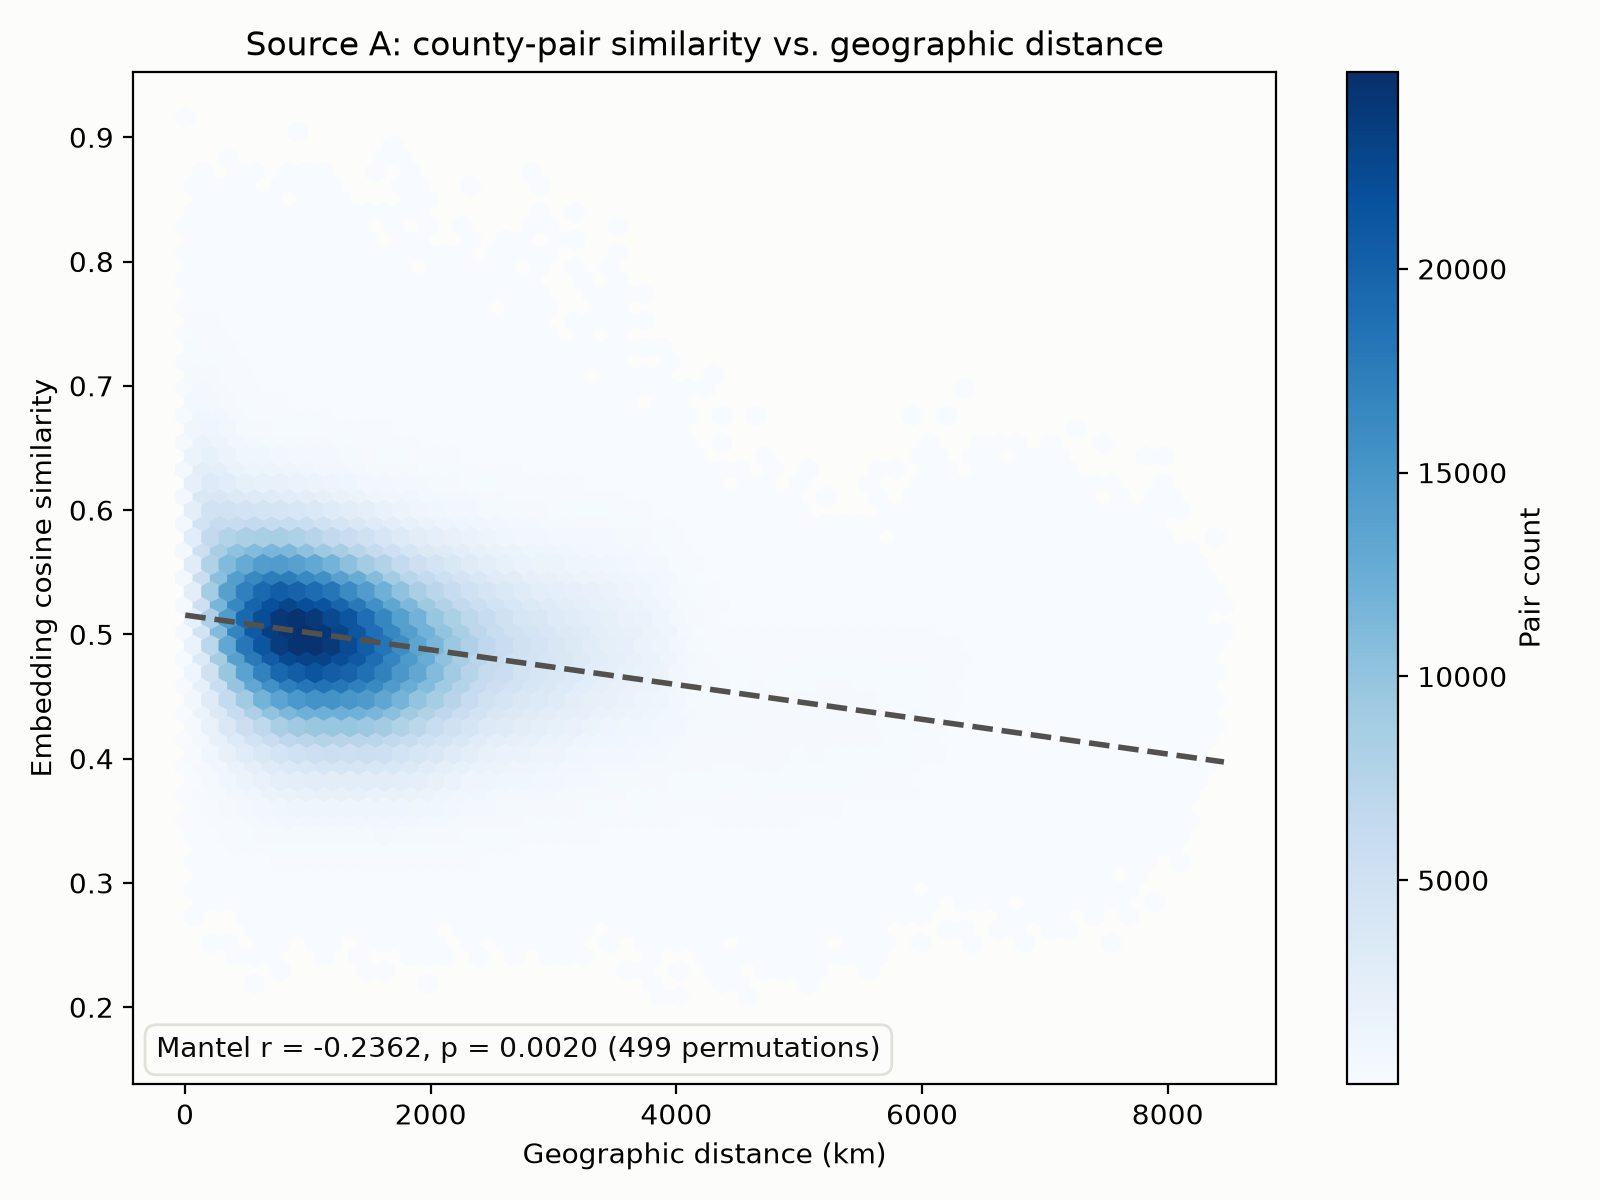

In [2]:
sil = pd.Series(embed_stats["silhouette_scores_by_k"]).astype(float)
sil.index = sil.index.astype(int)
sil = sil.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4),
                         gridspec_kw={"width_ratios": [1, 1.15]})
axes[0].bar(sil.index, sil.values, color="#7a9cc6")
axes[0].bar([embed_stats["selected_k"]], [embed_stats["selected_k_silhouette"]],
            color="#2f5d8a", label=f"selected k = {embed_stats['selected_k']}")
axes[0].axhline(0.25, color="#c1440e", lw=1.5, ls="--",
                label="0.25, the usual 'real structure' threshold")
axes[0].set_xlabel("k")
axes[0].set_ylabel("silhouette")
axes[0].set_title("K-means never finds structure worth the name")
axes[0].legend(fontsize=8)

cluster_km = pd.Series(embed_stats["cluster_mean_intra_km"]).astype(float)
corpus_km = embed_stats["corpus_mean_pairwise_km"]
axes[1].bar(cluster_km.index, cluster_km.values, color="#7a9cc6")
axes[1].axhline(corpus_km, color="#c1440e", lw=1.5,
                label=f"corpus mean {corpus_km:,.0f} km")
axes[1].set_ylabel("mean intra-cluster distance (km)")
axes[1].set_title("What the k=2 split does separate: geography, weakly")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Mantel r = {embed_stats['mantel_r']:.4f}, p = {embed_stats['mantel_p']:.4f} "
      f"({embed_stats['mantel_n_permutations']} permutations, seed "
      f"{embed_stats['mantel_seed']}, n = {embed_stats['clustering_n_counties']:,})")
print("  -- against GEOGRAPHIC distance. Negative: nearby counties are very")
print("     slightly more textually similar. This is not an economic yardstick,")
print("     and §13 onward stops using it.")
print(f"PC1 explains {embed_stats['pc1_explained_variance_ratio']:.3%} of variance "
      f"(n = {embed_stats['pc1_n_counties']:,}); its theme is a Texas")
print("     founding-narrative editorial artifact (§3.2), not economic content.")
print(f"best silhouette across all k tried: {sil.max():.4f} at k = {sil.idxmax()}")

display(Image(filename=str(FIGURES / "figure-01-similarity-vs-distance.png")))

### Why the embedding was cut, and what replaced it

**It was not cut for lack of signal.** Against the 28-target cross-pillar basket
the embedding beat the `content_length` scalar it was compared to, on a majority
of targets and at a significant paired test. It was cut on **cost**: a 2.2GB
model and CPU inference over every county article, for a mean R² lift in the
third decimal place. That left Source A shipping one scalar — article length —
and §13 asked whether cheap typed extraction could do better.

The figures below are the current re-score of that comparison, against the
Census-population size baseline adopted 2026-08-04 (§18). Any figure from §13
or §14 quoted without saying which size baseline produced it is not quotable;
the two sets differ in the fourth decimal throughout, and in the third for `p`.

In [3]:
print(f"cross-pillar lift over the size-plus-state baseline, "
      f"{rep_stats['n_targets']} targets (Census-population baseline, §18):")
print(f"  content_length (incumbent scalar) {rep_stats['mean_lift_length']:+.5f}")
print(f"  bge-m3 PCA-{rep_stats['n_components']:<20} {rep_stats['mean_lift_pca50']:+.5f}")
print(f"  bge-m3 full (1024 dim)            {rep_stats['mean_lift_full']:+.5f}  "
      f"beats the scalar on {rep_stats['n_embedding_wins']}/{rep_stats['n_targets']}, "
      f"Wilcoxon p = {rep_stats['wilcoxon_p']:.4g}")
print()
share_kept = ((rep_stats["mean_lift_pca50"] - rep_stats["mean_lift_length"])
              / (rep_stats["mean_lift_full"] - rep_stats["mean_lift_length"]))
print("So the embedding won on the measurement -- and lost on price. PCA is")
print("separately ruled out for this corpus (§13.7): the highest-variance")
print("direction is the Texas founding-narrative artifact, so a variance")
print(f"criterion selects against economic content -- PCA-{rep_stats['n_components']} keeps")
print(f"only {share_kept:.0%} of the full width's advantage over the incumbent scalar.")

cross-pillar lift over the size-plus-state baseline, 28 targets (Census-population baseline, §18):
  content_length (incumbent scalar) +0.00118
  bge-m3 PCA-50                   +0.00164
  bge-m3 full (1024 dim)            +0.00281  beats the scalar on 20/28, Wilcoxon p = 0.001172

So the embedding won on the measurement -- and lost on price. PCA is
separately ruled out for this corpus (§13.7): the highest-variance
direction is the Texas founding-narrative artifact, so a variance
criterion selects against economic content -- PCA-50 keeps
only 29% of the full width's advantage over the incumbent scalar.


## Part two — typed extraction, and the first control that bit (§13–§18)

If a dense embedding is too expensive, extract the same content as typed
columns. §13 wrote 20 regex-derived columns from each lead — industry family
flags, institution and transport flags, metro attachment, namesake, founding
year, a distinct-proper-noun count — under one uniform schema for all counties,
where **absence is `False`, not null**, so the sparsity of a stub county's row
*is* its tier. §14 reopened body sections and added nine economy-section
columns. That 29-column block is what ships.

Two design points did the work and are worth carrying forward: precision was
checked on sampled matches and two flags failed it (`has_military_base` was
catching "Fort Wayne", `has_tribal_land` was catching "American Indian Wars"),
which is what separates lexicon extraction from plausible-looking noise; and
tier membership is used to route work and break out results, never as a feature.

**Why the corpus's unevenness is the whole story.** Splitting counties into
content tiers on article length shows named industry content concentrated
almost entirely in the richest tier and near-absent below it. A dense
representation averaged over every county is therefore dominated by counties
with nothing to say — which is precisely where extraction contributes nothing
and correctly so.

,n_counties,min_length,max_length,mean_length,share_any_industry,mean_industry_mentions,mean_proper_nouns,share_founding_year
stub,294.0,33.0,99.0,63.8,0.0068,0.010,1.81,0.0544
thin,1274.0,100.0,283.0,191.4,0.0110,0.013,5.17,0.3297
mid,788.0,284.0,461.0,359.4,0.0546,0.066,8.70,0.5228
rich,788.0,462.0,4403.0,863.2,0.2525,0.350,17.83,0.4645


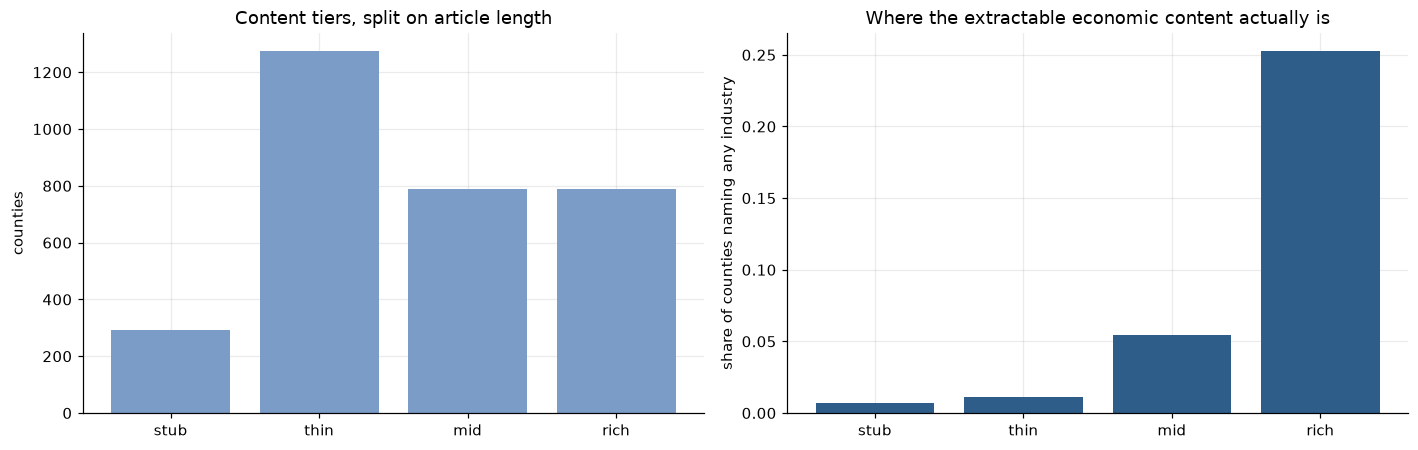

named industry is 23x more common in the 'rich' tier than 'thin' -- but only 8.2% of the
corpus carries it at all (3,144 counties, 16 of which quote USDA's own classification back
and are flagged as a circularity detector, never scored as a feature, §13.6).


In [4]:
tiers = pd.DataFrame(tier_stats["summary"]).T.loc[tier_stats["tier_labels"]]
display(tiers)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(tiers.index, tiers["n_counties"], color="#7a9cc6")
axes[0].set_ylabel("counties")
axes[0].set_title("Content tiers, split on article length")
axes[1].bar(tiers.index, tiers["share_any_industry"], color="#2f5d8a")
axes[1].set_ylabel("share of counties naming any industry")
axes[1].set_title("Where the extractable economic content actually is")
fig.tight_layout()
plt.show()

richest, thinnest = tier_stats["tier_labels"][-1], tier_stats["tier_labels"][1]
ratio = tiers.loc[richest, "share_any_industry"] / tiers.loc[thinnest, "share_any_industry"]
print(f"named industry is {ratio:.0f}x more common in the '{richest}' tier than "
      f"'{thinnest}' -- but only {extract_stats['share_any_industry']:.1%} of the")
print(f"corpus carries it at all ({extract_stats['n_counties']:,} counties, "
      f"{extract_stats['n_usda_echo']} of which quote USDA's own classification back")
print("and are flagged as a circularity detector, never scored as a feature, §13.6).")

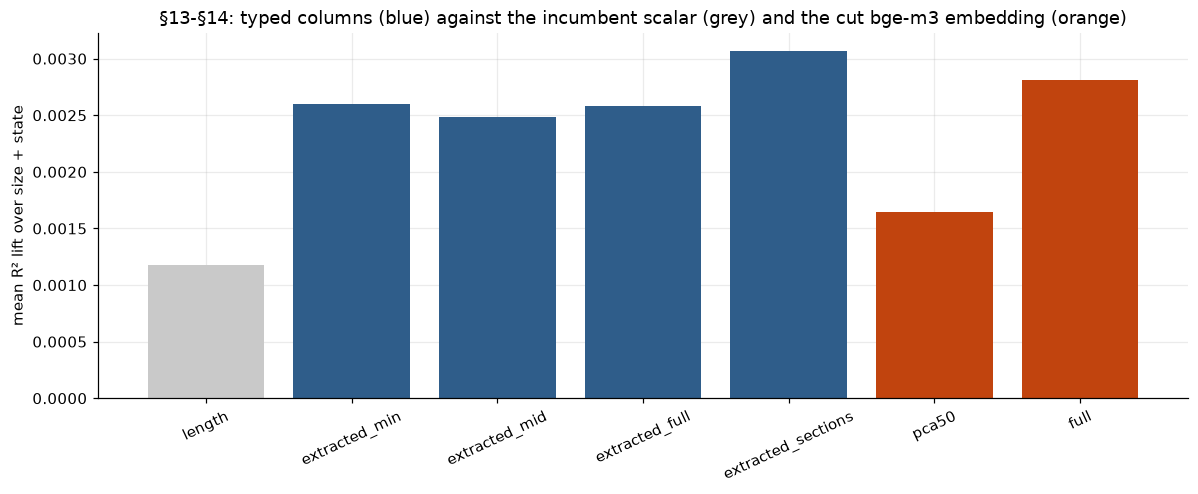

,variant,mean_lift,r2_alone,wins_vs_incumbent,wilcoxon_p
0,length,0.001176,0.019823,--,NaN
1,extracted_min,0.002598,0.042376,13/28,0.41173
2,extracted_mid,0.002485,0.042032,17/28,0.12562
3,extracted_full,0.002580,0.044359,14/28,0.45148
4,extracted_sections,0.003072,0.047712,18/28,0.11452
5,pca50,0.001643,0.085024,15/28,0.69470
6,full,0.002808,0.112214,19/28,0.01184


shipped block: 29 typed columns, mean lift +0.00307, r2_alone 0.0477
against the incumbent scalar (length): 18/28 targets, p = 0.115, power 0.51 -- 61 targets would be needed for 0.80.
head to head against the 1024-dim embedding (extracted_sections - full): +0.00026, 11/28, p = 0.52, power 0.09.

Read those two rows together and the conclusion is narrow: the typed block
leads the incumbent on mean lift and is not shown to beat it target by
target, and it is a TIE with the embedding, not a win. The case for the
typed block is cost and interpretability -- not measured advantage.


In [5]:
order = ["length", "extracted_min", "extracted_mid", "extracted_full",
         "extracted_sections", "pca50", "full"]
incumbent = rep_stats["incumbent"]
variants = pd.DataFrame([
    {"variant": name,
     "mean_lift": rep_stats["variants"][name]["mean_lift"],
     "r2_alone": rep_stats["variants"][name]["mean_r2_alone"],
     # the incumbent cannot beat itself; blank rather than a misleading 0/28.
     "wins_vs_incumbent": (f"{rep_stats['variants'][name]['n_wins_vs_incumbent']}"
                           f"/{rep_stats['n_targets']}" if name != incumbent else "--"),
     "wilcoxon_p": (round(rep_stats["variants"][name]["wilcoxon_p"], 5)
                    if name != incumbent else None)}
    for name in order
])

fig, ax = plt.subplots(figsize=(11, 4.6))
colors = ["#c9c9c9" if v == incumbent else "#c1440e" if v in ("pca50", "full")
          else "#2f5d8a" for v in variants["variant"]]
ax.bar(variants["variant"], variants["mean_lift"], color=colors)
ax.set_ylabel("mean R² lift over size + state")
ax.set_title("§13-§14: typed columns (blue) against the incumbent scalar (grey) "
             "and the cut bge-m3 embedding (orange)")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

display(variants)

shipped = rep_stats["variants"]["extracted_sections"]
head = rep_stats["typed_vs_embedding"]
print(f"shipped block: {struct_stats['n_typed_features']} typed columns, mean lift "
      f"{shipped['mean_lift']:+.5f}, r2_alone {shipped['mean_r2_alone']:.4f}")
print(f"against the incumbent scalar ({incumbent}): "
      f"{shipped['n_wins_vs_incumbent']}/"
      f"{rep_stats['n_targets']} targets, p = {shipped['wilcoxon_p']:.3f}, "
      f"power {shipped['effect']['power']:.2f} -- "
      f"{shipped['effect']['n_for_80']} targets would be needed for 0.80.")
print(f"head to head against the 1024-dim embedding "
      f"({head['typed_variant']} - {head['embedding_variant']}): "
      f"{head['mean_difference']:+.5f}, {head['n_wins']}/{rep_stats['n_targets']}, "
      f"p = {head['wilcoxon_p']:.2f}, power {head['effect']['power']:.2f}.")
print()
print("Read those two rows together and the conclusion is narrow: the typed block")
print("leads the incumbent on mean lift and is not shown to beat it target by")
print("target, and it is a TIE with the embedding, not a win. The case for the")
print("typed block is cost and interpretability -- not measured advantage.")

### §17 — the first honest baseline, and the first collapse

Every lift above is measured against county size plus state. No downstream
consumer sees that baseline: a fused model has all six pillars. §17 ran the
configuration that matters — baseline = size + state + **every pillar except
Source A and the target's own** — and Source A's measured value fell by roughly
70%.

**What survives is the load-bearing finding of the whole line.** Both variants
stay significantly positive against a baseline that already contains every other
pillar, the shipped block at the better-powered of the two tests. The typed
block keeps roughly twice the scalar's marginal value on the point estimate, but
that particular gap is *not* individually significant and is powered far too low
to be — it would need something like four times the basket. The shipping
decision rests on the first fact, not the second.

**And the retention gradient is the coherence check.** Source A survives where
its lexicons name something no federal statistic encodes, and is fully absorbed
where another pillar measures the same quantity directly. A feature set that
survived arbitrarily would look like noise; this one survives exactly where the
mechanism says it should.

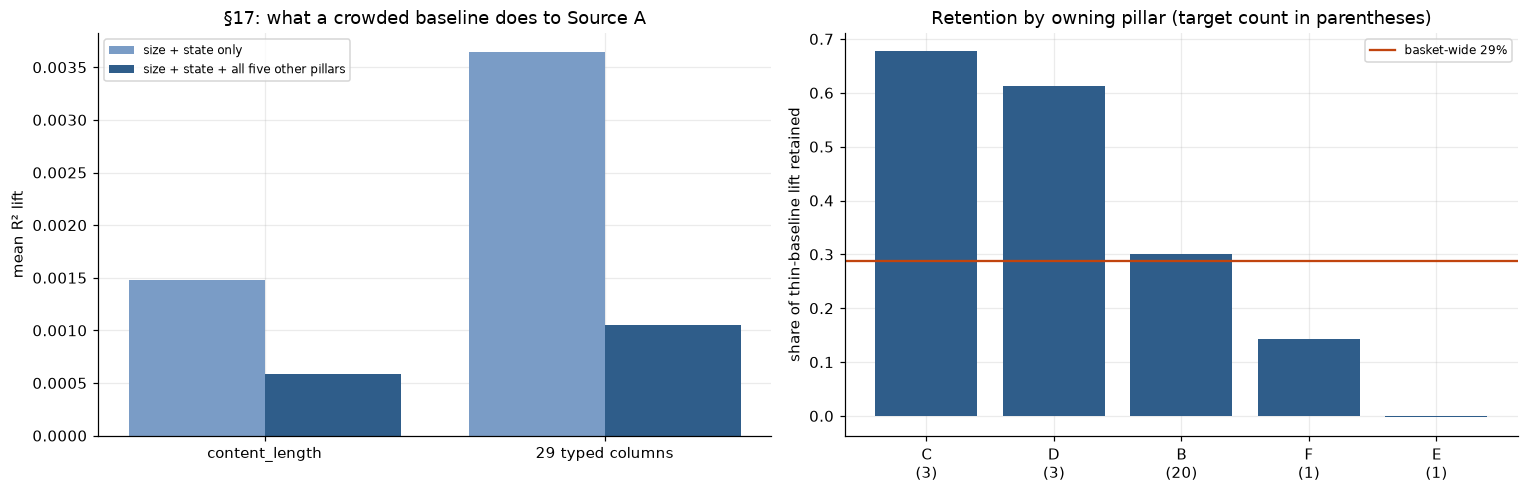

mean R² of the baseline itself: 0.2564 (size + state) -> 0.3267 (106 columns)

content_length  thin +0.00148 -> crowded +0.00059  (40% retained, 22/28, p = 0.003)
typed block     thin +0.00364 -> crowded +0.00105  (29% retained, 19/28, p = 0.010)

typed block vs zero, crowded baseline: power 0.34 at effective n = 28 (ICC 0.000, design effect 1.00) -- the nominal
  basket is very nearly the effective one, so this test needs no discount.
typed block vs the scalar:            +0.00046, 13/28, p = 0.493, power 0.34, 110 targets needed for 0.80.

Retention spans two orders of magnitude across pillars, and the basket is
71% its worst-retaining block, so the single aggregate is as much a
property of the target mix as of Source A:
pillar  n_targets  thin_length  crowded_length  thin_extracted_sections  crowded_extracted_sections  retained_length  retained_extracted_sections
     B         20      0.00122         0.00075                  0.00306                     0.00092          0.61022     

In [6]:
scalar = marg_stats["variants"]["length"]
typed = marg_stats["variants"]["extracted_sections"]
gap = marg_stats["typed_vs_scalar_crowded"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

x = np.arange(2)
for offset, key, label, color in ((-0.2, "mean_lift_thin", "size + state only", "#7a9cc6"),
                                  (0.2, "mean_lift_crowded",
                                   "size + state + all five other pillars", "#2f5d8a")):
    axes[0].bar(x + offset, [scalar[key], typed[key]], 0.4, label=label, color=color)
axes[0].set_xticks(x)
axes[0].set_xticklabels(["content_length", f"{struct_stats['n_typed_features']} typed columns"])
axes[0].set_ylabel("mean R² lift")
axes[0].set_title("§17: what a crowded baseline does to Source A")
axes[0].legend(fontsize=8)

pillars = marg_by_pillar.sort_values("retained_extracted_sections", ascending=False)
axes[1].bar([f"{p}\n({n})" for p, n in zip(pillars["pillar"], pillars["n_targets"])],
            pillars["retained_extracted_sections"], color="#2f5d8a")
axes[1].axhline(typed["share_retained"], color="#c1440e", lw=1.5,
                label=f"basket-wide {typed['share_retained']:.0%}")
axes[1].set_ylabel("share of thin-baseline lift retained")
axes[1].set_title("Retention by owning pillar (target count in parentheses)")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"mean R² of the baseline itself: {marg_stats['mean_r2_thin_baseline']:.4f} "
      f"(size + state) -> {marg_stats['mean_r2_crowded_baseline']:.4f} "
      f"({marg_stats['mean_baseline_columns']:.0f} columns)")
print()
for name, v in (("content_length", scalar), ("typed block", typed)):
    print(f"{name:15} thin {v['mean_lift_thin']:+.5f} -> crowded "
          f"{v['mean_lift_crowded']:+.5f}  ({v['share_retained']:.0%} retained, "
          f"{v['n_positive_crowded']}/{marg_stats['n_targets']}, "
          f"p = {v['wilcoxon_p_crowded']:.3f})")
print()
print(f"typed block vs zero, crowded baseline: power "
      f"{gap['clustering']['power_at_effective_n']:.2f} at effective n = "
      f"{gap['clustering']['n_effective']:.0f} (ICC {gap['clustering']['icc']:.3f}, "
      f"design effect {gap['clustering']['design_effect']:.2f}) -- the nominal")
print("  basket is very nearly the effective one, so this test needs no discount.")
print(f"typed block vs the scalar:            {gap['mean_difference']:+.5f}, "
      f"{gap['n_wins']}/{marg_stats['n_targets']}, p = {gap['wilcoxon_p']:.3f}, "
      f"power {gap['effect']['power']:.2f}, "
      f"{gap['effect']['n_for_80']} targets needed for 0.80.")
print()
print("Retention spans two orders of magnitude across pillars, and the basket is")
print("71% its worst-retaining block, so the single aggregate is as much a")
print("property of the target mix as of Source A:")
print(marg_by_pillar.round(5).to_string(index=False))

## Part three — a defect, and the reversal it exposed (§20–§22)

### §20 — the best arm had been reading a fraction of its input

§20 tested a natively small encoder (`all-MiniLM-L6-v2`, 384 dimensions,
~90MB against `bge-m3`'s 2.2GB) with the text chunked and mean-pooled, and found
a per-county chunk cap that had been silently truncating the widest-reading arm
on a **majority** of counties — the arm whose headline was "a small encoder
still loses". The cap was chosen so one enormous article could not dominate
runtime, its effect was logged honestly at the time, and nobody read the number
back.

*The pre-fix diagnostic — how many counties hit the old cap and how many
characters it discarded — lives in §20.1 of the register and in no committed
artifact, so it is not restated here. What the artifact carries is the post-fix
run, below: the cap is now effectively non-binding.*

Raised and re-run, **the small encoder no longer loses. It does not win
either.** Against the shipped typed block it is a tie on the cross-pillar
basket, which by this file's own standard (§14.2a) is what 28 targets can
resolve and no more. The consequence is narrow and worth stating precisely:
the typed block's case was never lift, and now it rests entirely on cost and
interpretability rather than partly on measured advantage.

encoder: sentence-transformers/all-MiniLM-L6-v2, 384 dim, chunked at 900 chars, cap now 64 chunks/county
post-fix, the cap binds on 47 of 3,144 counties (1.5%) and drops 1.39M characters -- effectively non-binding.
the 'uniform' arm reads a mean of 12,743 characters per county.



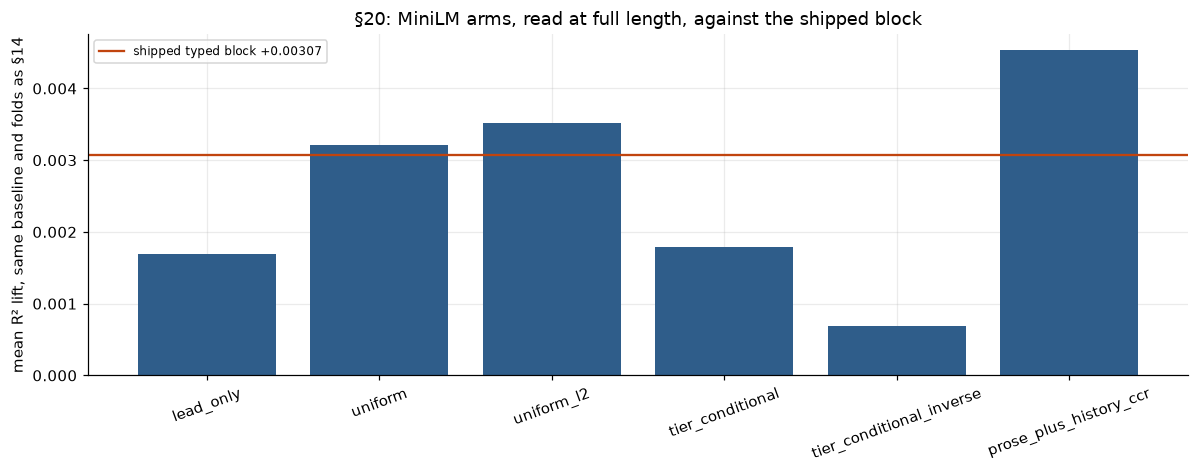

,arm,mean_lift,beats_typed_on
0,lead_only,0.00169,8
1,uniform,0.00322,13
2,uniform_l2,0.00351,14
3,tier_conditional,0.00180,9
4,tier_conditional_inverse,0.00068,9
5,prose_plus_history_ccr,0.00453,18


paired against the shipped typed block, target by target:
  uniform_l2   - typed:  mean +0.00044, median -0.00001, 14/28 wins, p = 0.762
  uniform      - typed:  mean +0.00015, median -0.00028, 13/28 wins, p = 0.745
a median at essentially zero on half the basket is a tie, and this file's
own standard (§14.2a) is that 28 targets cannot resolve differences this small.
the tier ordering also survives -- 'uniform' (+0.00322) over 'tier_conditional' (+0.00180) over 'tier_conditional_inverse' (+0.00068),
  so the INPUT should not branch on tier either, which is §15's answer
  reached again on different machinery.


In [7]:
diag = tiered_stats["text_diagnostics"]["uniform"]
n_counties = extract_stats["n_counties"]
print(f"encoder: {tiered_stats['encoder']}, {tiered_stats['n_dimensions']} dim, "
      f"chunked at {tiered_stats['chunk_chars']} chars, cap now "
      f"{tiered_stats['max_chunks_per_county']} chunks/county")
print(f"post-fix, the cap binds on {diag['counties_hitting_cap']:,.0f} of "
      f"{n_counties:,} counties ({diag['counties_hitting_cap'] / n_counties:.1%}) and drops "
      f"{diag['chars_dropped_by_cap'] / 1e6:.2f}M characters -- effectively non-binding.")
print(f"the 'uniform' arm reads a mean of {diag['mean_chars']:,.0f} characters per county.")
print()

arms = ["lead_only", "uniform", "uniform_l2", "tier_conditional",
        "tier_conditional_inverse", "prose_plus_history_ccr"]
enc = pd.DataFrame([
    {"arm": a,
     "mean_lift": tiered_stats["representations"][a]["mean_lift"],
     "beats_typed_on": tiered_stats["representations"][a]["n_targets_beating_typed"]}
    for a in arms
])
typed_lift = rep_stats["variants"]["extracted_sections"]["mean_lift"]

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.bar(enc["arm"], enc["mean_lift"], color="#2f5d8a")
ax.axhline(typed_lift, color="#c1440e", lw=1.5,
           label=f"shipped typed block {typed_lift:+.5f}")
ax.set_ylabel("mean R² lift, same baseline and folds as §14")
ax.set_title("§20: MiniLM arms, read at full length, against the shipped block")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

display(enc.round(5))

# The paired comparison itself, recomputed from the two committed per-target
# tables -- a mean and a win count are not enough to call a tie.
per_target_enc = pd.read_csv(OUTPUTS / "source_a_tiered_embedding.csv",
                             float_precision="round_trip")
per_target_rep = pd.read_csv(OUTPUTS / "source_a_representation.csv",
                             float_precision="round_trip")
typed_per_target = per_target_rep.set_index("column")["lift_extracted_sections"]
print("paired against the shipped typed block, target by target:")
for arm in ("uniform_l2", "uniform"):
    arm_per_target = (per_target_enc[per_target_enc["representation"] == arm]
                      .set_index("column")["lift"])
    shared = typed_per_target.index.intersection(arm_per_target.index)
    delta = arm_per_target[shared] - typed_per_target[shared]
    test = wilcoxon(arm_per_target[shared], typed_per_target[shared])
    print(f"  {arm:12} - typed:  mean {delta.mean():+.5f}, median {delta.median():+.5f}, "
          f"{int((delta > 0).sum())}/{len(delta)} wins, p = {test.pvalue:.3f}")
print("a median at essentially zero on half the basket is a tie, and this file's")
print("own standard (§14.2a) is that 28 targets cannot resolve differences this small.")
print(f"the tier ordering also survives -- 'uniform' "
      f"({tiered_stats['representations']['uniform']['mean_lift']:+.5f}) over "
      f"'tier_conditional' "
      f"({tiered_stats['representations']['tier_conditional']['mean_lift']:+.5f}) over "
      f"'tier_conditional_inverse' "
      f"({tiered_stats['representations']['tier_conditional_inverse']['mean_lift']:+.5f}),")
print("  so the INPUT should not branch on tier either, which is §15's answer")
print("  reached again on different machinery.")

### §21 — is the near-zero about the pillar, or about how it is encoded?

Source A's contribution on the drop-one test against external ACS targets —
withhold its block from a model holding county size and the other five pillars —
was a published **−0.0000**. That was measured with Source A as typed columns,
and §20 had just shown a MiniLM embedding tying those columns elsewhere. So:
pillar, or encoding?

§21 answered "pillar" on a five-target slice: the typed arm reproduced the
published near-zero, and swapping in the raw 384-dimension embedding made the
contribution *dramatically worse*, negative on every target, three orders of
magnitude apart. The five rows below are that slice, read out of the current
committed per-target table — they reproduce §21's figures exactly.

**§22 then showed that conclusion was too general.** It was true of the arms
§21 tested. It is not true of representation choice in general.

In [8]:
slice_targets = list(repmarg_stats["by_representation"]["typed"]["by_target"])[:5]
arms21 = ["typed", "minilm_uniform", "minilm_uniform_l2"]
tbl21 = (repmarg[repmarg["target"].isin(slice_targets)]
         .pivot(index="target", columns="representation", values="contribution")
         .loc[slice_targets, arms21])
display(tbl21.round(5))
print("mean over this five-target slice:")
for arm, value in tbl21.mean().items():
    print(f"  {arm:20} {value:+.5f}")
print()
print("the typed arm reproduces the published near-zero from a separately")
print("assembled harness, which is the check that makes the other two rows")
print("worth reading. The embedding arms carry 384 columns against 29, so part")
print("of the penalty is width rather than content -- a width-matched arm is")
print("exactly what §22 goes on to score.")

representation,typed,minilm_uniform,minilm_uniform_l2
target,,,
broadband_rate,-0.00256,-0.01984,-0.01607
median_household_income,-0.00316,-0.04216,-0.03559
median_age,0.00696,-0.05394,-0.04141
median_home_value,-0.00251,-0.04845,-0.03104
mean_commute_minutes,0.00104,-0.05437,-0.05081


mean over this five-target slice:
  typed                -0.00005
  minilm_uniform       -0.04375
  minilm_uniform_l2    -0.03499

the typed arm reproduces the published near-zero from a separately
assembled harness, which is the check that makes the other two rows
worth reading. The embedding arms carry 384 columns against 29, so part
of the penalty is width rather than content -- a width-matched arm is
exactly what §22 goes on to score.


### §22 — the pre-registered decision, and the geography control that undid it

A decision rule was pre-registered and committed *before* any new arm was
scored: score the typed block's capacity-equalized variant against whichever
text scope won selection on a disjoint basket, PCA-reduced to the typed block's
own width, on the expanded external decision basket, out-of-fold on held-out
states. The selected arm was `prose_plus_history` text with the common component
removed, reduced to 29 dimensions inside each fold.

**The selected embedding arm won outright.** Not a tie: the register's paired
bootstrap interval sat entirely below zero on both baskets, and the paired
Wilcoxon below — recomputed here from the committed per-target table — agrees.
Two details of that win belong beside it. The pre-registered capacity pass
**backfired**: the transformed typed block scores worse than the raw typed block
it was built to equalize. And one target was excluded from every headline as
degenerate (§22.1) — its baseline R² is worse than predicting the panel mean, so
a "contribution" there is the gap between two useless models.

Naming matters here: the **unselected raw** MiniLM arms still lose badly, as
§21 found. Only the selected, common-component-removed, width-matched arm wins.

In [9]:
SELECTED = "minilm_prose_plus_history_ccr_pca29"
COMPARATOR = "typed_transformed"
by_rep = repmarg_stats["by_representation"]

table = (pd.DataFrame(by_rep).T[["n_columns", "decision_basket_mean_contribution",
                                 "decision_basket_median_contribution",
                                 "decision_basket_n_positive",
                                 "decision_basket_n_targets",
                                 "decision_basket_mean_contribution_geo"]]
         .sort_values("decision_basket_mean_contribution", ascending=False))
display(table.round(5))

kept = repmarg[~repmarg["excluded"]]
pivot = kept.pivot(index="target", columns="representation", values="contribution")
paired = (pivot[COMPARATOR] - pivot[SELECTED]).dropna()
stat = wilcoxon(pivot[SELECTED], pivot[COMPARATOR])
n_basket = len(paired)

print(f"decision basket: n = {n_basket} "
      f"({repmarg_stats['n_targets']} scored, "
      f"{len(repmarg_stats['excluded_targets'])} excluded as degenerate, §22.1)")
print(f"excluded: {', '.join(repmarg_stats['excluded_targets'])}")
print(f"targets whose baseline R² is negative and are flagged rather than averaged "
      f"in silently: {', '.join(repmarg_stats['negative_baseline_targets'])}")
print()
print(f"Rule 4, paired difference ({COMPARATOR} - selected), decision basket:")
print(f"  mean {paired.mean():+.6f}   selected wins on "
      f"{int((pivot[SELECTED] > pivot[COMPARATOR]).sum())}/{n_basket}   "
      f"Wilcoxon p = {stat.pvalue:.6f}")
print("  The register's pre-registered bootstrap CI sits entirely below zero on")
print("  both this basket and the leakage-clean subset (§22.1). This is not a tie.")
print()
print(f"the capacity pass backfired: {COMPARATOR} "
      f"({by_rep[COMPARATOR]['decision_basket_mean_contribution']:+.6f}) scores WORSE than")
print(f"the raw typed block it was built to equalize "
      f"({by_rep['typed']['decision_basket_mean_contribution']:+.6f}).")
print(f"the unselected raw arms still lose: minilm_uniform "
      f"{by_rep['minilm_uniform']['decision_basket_mean_contribution']:+.6f}, "
      f"minilm_uniform_l2 "
      f"{by_rep['minilm_uniform_l2']['decision_basket_mean_contribution']:+.6f}.")

,n_columns,decision_basket_mean_contribution,decision_basket_median_contribution,decision_basket_n_positive,decision_basket_n_targets,decision_basket_mean_contribution_geo
minilm_prose_plus_history_ccr_pca29,29,0.016397,0.011041,37,41,0.000607
latlong_only,2,0.01579,0.005373,25,41,0.0
minilm_uniform_ccr_pca29,29,0.013474,0.0059,36,41,-0.002316
minilm_uniform_pca29,29,0.010985,0.005096,30,41,-0.004806
minilm_uniform_pca64,64,0.007893,-0.00054,20,41,-0.007897
typed,29,0.003139,0.000482,23,41,-0.012651
typed_transformed,37,0.001654,0.000741,22,41,-0.014137
minilm_uniform_l2,384,-0.006475,-0.016067,11,41,-0.022265
minilm_uniform,384,-0.013696,-0.018585,9,41,-0.029486


decision basket: n = 41 (42 scored, 1 excluded as degenerate, §22.1)
excluded: no_fuel_used_share
targets whose baseline R² is negative and are flagged rather than averaged in silently: fuel_oil_heating_share, no_fuel_used_share

Rule 4, paired difference (typed_transformed - selected), decision basket:
  mean -0.014744   selected wins on 33/41   Wilcoxon p = 0.000021
  The register's pre-registered bootstrap CI sits entirely below zero on
  both this basket and the leakage-clean subset (§22.1). This is not a tie.

the capacity pass backfired: typed_transformed (+0.001654) scores WORSE than
the raw typed block it was built to equalize (+0.003139).
the unselected raw arms still lose: minilm_uniform -0.013696, minilm_uniform_l2 -0.006475.


#### §22.2 — and then two columns of latitude and longitude

`GroupKFold` on state stops a county's own row leaking into its training fold.
It does not stop an encoder reading *regional vocabulary*: dialect, place names,
climate description. The selected arm's biggest per-target gains were exactly
the outcomes regional climate and settlement pattern would predict — heating
fuel, commute mode, year built. So two columns were added to the reduced model:
the county's centroid latitude and longitude.

**Most of the selected arm's own contribution is a geography proxy.** Two
floating-point columns reach nearly all of what twenty-nine PCA components of a
sentence embedding reach, and once they are in the model the selected arm's
marginal value collapses to approximately zero, with its win rate falling to
roughly a coin flip.

Two things must be said together about what that does to the verdict. The
pre-registered comparison — selected arm against the typed comparator — is
**mathematically unaffected**, because a paired difference cancels any baseline
shared by both arms; the win survives in full. What does not survive is the
selected arm's value over *not using Source A at all*. And the currently
shipped typed variant's own value net of geography is not merely small but
substantially negative. Reporting only the first of those would overstate the
result.

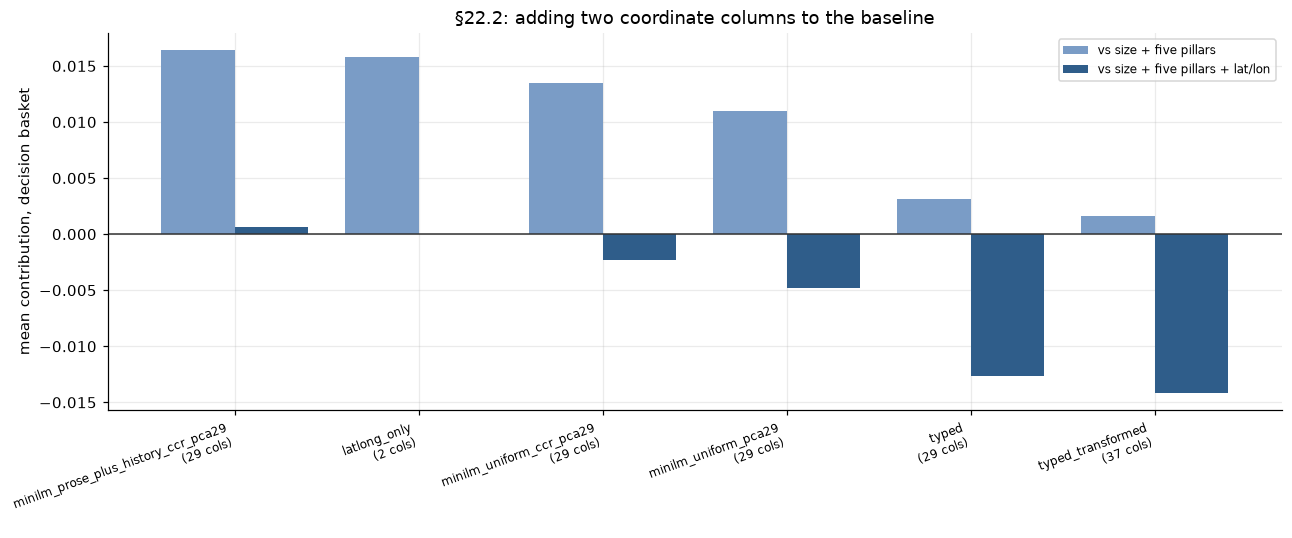

,arm,n_columns,plain,net_of_latlong,n_positive_plain
0,minilm_prose_plus_history_ccr_pca29,29,0.01640,0.00061,37
1,latlong_only,2,0.01579,0.00000,25
2,minilm_uniform_ccr_pca29,29,0.01347,-0.00232,36
3,minilm_uniform_pca29,29,0.01098,-0.00481,30
4,typed,29,0.00314,-0.01265,23
5,typed_transformed,37,0.00165,-0.01414,22


two coordinate columns alone reach +0.015790, which is 96% of the selected arm's own +0.016397,
using 2 columns against 29.
net of lat/lon the selected arm falls to +0.000607, and its win rate goes from
37/41 to roughly a coin flip.

per-target, the collapse lands where the mechanism predicts -- climate- and
settlement-flavoured targets invert sign, while a few hold up or strengthen:


,contribution,contribution_geo
target,,
electric_heating_share,0.1253,-0.0150
fuel_oil_heating_share,0.1010,-0.0341
drove_alone_share,0.0317,-0.0574
mean_commute_minutes,0.0270,-0.0111
gas_heating_share,0.0612,0.0814
foreign_born_share,0.0406,0.0440
median_year_built,0.0382,0.0456


In [10]:
geo_arms = [SELECTED, "latlong_only", "minilm_uniform_ccr_pca29",
            "minilm_uniform_pca29", "typed", COMPARATOR]
geo = pd.DataFrame([
    {"arm": a, "n_columns": by_rep[a]["n_columns"],
     "plain": by_rep[a]["decision_basket_mean_contribution"],
     "net_of_latlong": by_rep[a]["decision_basket_mean_contribution_geo"],
     "n_positive_plain": by_rep[a]["decision_basket_n_positive"]}
    for a in geo_arms
])

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(geo))
ax.bar(x - 0.2, geo["plain"], 0.4, label="vs size + five pillars", color="#7a9cc6")
ax.bar(x + 0.2, geo["net_of_latlong"], 0.4,
       label="vs size + five pillars + lat/lon", color="#2f5d8a")
ax.set_xticks(x)
ax.set_xticklabels([f"{a}\n({c} cols)" for a, c in zip(geo["arm"], geo["n_columns"])],
                   rotation=20, ha="right", fontsize=8)
ax.axhline(0, color="#333", lw=1)
ax.set_ylabel("mean contribution, decision basket")
ax.set_title("§22.2: adding two coordinate columns to the baseline")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

display(geo.round(5))

sel, latlon = by_rep[SELECTED], by_rep["latlong_only"]
share = (latlon["decision_basket_mean_contribution"]
         / sel["decision_basket_mean_contribution"])
print(f"two coordinate columns alone reach "
      f"{latlon['decision_basket_mean_contribution']:+.6f}, which is {share:.0%} of the "
      f"selected arm's own {sel['decision_basket_mean_contribution']:+.6f},")
print(f"using {latlon['n_columns']} columns against {sel['n_columns']}.")
print(f"net of lat/lon the selected arm falls to "
      f"{sel['decision_basket_mean_contribution_geo']:+.6f}, and its win rate goes from")
print(f"{sel['decision_basket_n_positive']}/{sel['decision_basket_n_targets']} to roughly "
      "a coin flip.")
print()
print("per-target, the collapse lands where the mechanism predicts -- climate- and")
print("settlement-flavoured targets invert sign, while a few hold up or strengthen:")
watch = ["electric_heating_share", "fuel_oil_heating_share", "drove_alone_share",
         "mean_commute_minutes", "gas_heating_share", "foreign_born_share",
         "median_year_built"]
per_target = (repmarg[(repmarg["representation"] == SELECTED)
                      & (repmarg["target"].isin(watch))]
              .set_index("target").loc[watch, ["contribution", "contribution_geo"]])
display(per_target.round(4))

## Part four — article shape, and a null control that outscored it (§23)

Everything so far reads content. §23 asked the remaining question: how much of a
county can be read off the **shape** of its Wikipedia article — how many
sections, how long, which titles are present — with no text read at all? Sixty-
four columns, derived from nothing but a section's title and its character
count.

The block lifted over the size-plus-state baseline, significantly. Then the
round did the thing that turned out to matter: it ran an **information-free null
control** through the identical protocol — squares, cubes and pairwise products
of the baseline's *own three size columns*, carrying nothing the baseline lacks
— and that block scored several times the structural block's lift.

**The correction that follows is the round's central finding.** The design, the
module docstring and the previous notebook all claimed that fitting each arm to
the residuals of the size-plus-state model made a pure size proxy worth
approximately nothing. That claim was false, and the round had been approved on
it. The baseline holds size **linearly, in logs**. So a lift in this protocol
means "knows something a *linear-in-logs* size model does not" — and any
monotone-but-curved relationship with county size clears that bar carrying no
content whatsoever.

Under a flexible baseline that adds those nine curvature directions and adds no
information (mean baseline R² barely moves), roughly a quarter of the structural
lift survives on the full basket — and on the 22 targets where the augmented
baseline did not itself degrade, it is not significant at all. Both readings are
below; quoting either alone misstates the result. The null control, scored
against that same augmented baseline, goes to zero, which is the construction
check.

,arm,tested against,linear_diff,linear_wins,linear_p,flex_all28_diff,flex_all28_wins,flex_all28_p,flex_undeg22_diff,flex_undeg22_wins,flex_undeg22_p,lift_over_baseline_linear,retained
0,structure,baseline,0.00269,21/28,0.00117,0.00073,20/28,0.02805,0.00062,15/22,0.20993,0.00269,0.27317
1,typed,baseline,0.00307,22/28,0.00038,0.00161,18/28,0.01102,0.00148,13/22,0.12888,0.00307,0.52462
2,typed_plus_structure,typed,0.00184,20/28,0.01184,0.00095,18/28,0.13147,0.00091,14/22,0.29022,0.00491,0.51562
3,size_nonlinear,baseline,0.01748,26/28,0.00000,0.00000,15/28,0.11282,0.00000,10/22,0.52021,0.01748,0.00000


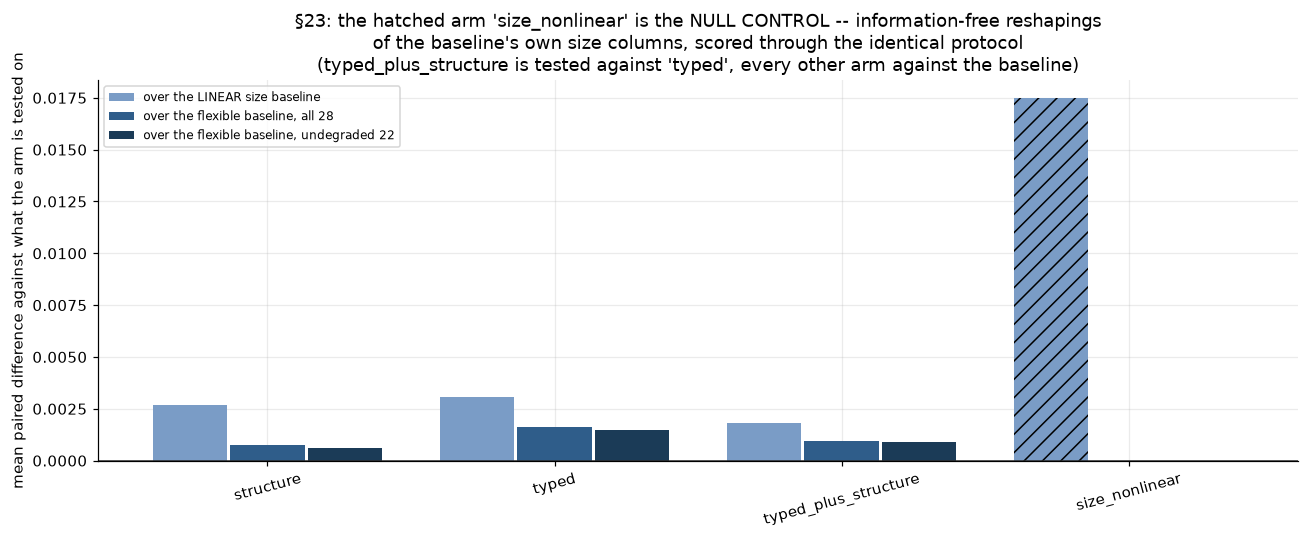

baseline mean R²: 0.2612 (linear) -> 0.2607 (curvature-augmented, 9 directions)
the augmentation adds NO information and moves the baseline barely at all,
which is what makes it a fair control rather than a stronger model.

structural block (64 columns): +0.00269, 21/28, p = 0.0012
NULL CONTROL   (9 columns): +0.01748, 26/28, p = 1.3e-06
the structural lift is 0.154 of the null control's -- i.e. the information-free block scores 6.5x the finding.

the flexible baseline degrades on 6 of 28 targets, so both denominators are reported and neither alone:
  capital_to_wage_ratio, distress_count, lq_emp_31-33, out_partner_hhi, unemployment_rate_latest, unemployment_velocity

the fusion comparison -- typed_plus_structure against typed, the one
comparison that would argue for shipping these columns -- does not survive:
  +0.00095 against 'typed', 18/28, p = 0.1315 (all 28);
  +0.00091, 14/22, p = 0.2902 (undegraded 22).
  Note this row's difference is against 'typed', not against the baseline -

In [11]:
STRUCT_ARMS = ["structure", "typed", "typed_plus_structure", "size_nonlinear"]
NULL = struct_stats["null_arm_key"]


# One row per arm, reporting the quantity the arm's own comparison tests.
# `mean_lift` is always lift over the baseline; `mean_paired_difference` is what
# the arm's `wilcoxon_p` actually tests, which for the fusion arm is the
# difference against `typed`, not against the baseline. Reporting the former
# under the latter's p-value is exactly the framing error §23 exists to
# document, so this table carries the tested quantity.
def struct_row(arm):
    lin = struct_stats["arms"][arm]
    flex = struct_stats["arms_flexible"][arm]
    undeg = struct_stats["arms_flexible_undegraded"][arm]
    return {
        "arm": arm, "tested against": lin["compared_against"],
        "linear_diff": lin["mean_paired_difference"],
        "linear_wins": f"{lin['n_wins']}/{lin['n_targets']}",
        "linear_p": lin["wilcoxon_p"],
        "flex_all28_diff": flex["mean_paired_difference"],
        "flex_all28_wins": f"{flex['n_wins']}/{flex['n_targets']}",
        "flex_all28_p": flex["wilcoxon_p"],
        "flex_undeg22_diff": undeg["mean_paired_difference"],
        "flex_undeg22_wins": f"{undeg['n_wins']}/{undeg['n_targets']}",
        "flex_undeg22_p": undeg["wilcoxon_p"],
        "lift_over_baseline_linear": lin["mean_lift"],
        "retained": struct_stats["flexible_retention"][arm],
    }


struct = pd.DataFrame([struct_row(a) for a in STRUCT_ARMS])
display(struct.round(5))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(struct))
series = (("linear_diff", "over the LINEAR size baseline", "#7a9cc6", -0.27),
          ("flex_all28_diff", "over the flexible baseline, all 28", "#2f5d8a", 0.0),
          ("flex_undeg22_diff", "over the flexible baseline, undegraded 22", "#1b3b57", 0.27))
for column, label, color, offset in series:
    bars = ax.bar(x + offset, struct[column], 0.26, label=label, color=color)
    for bar, arm in zip(bars, struct["arm"]):
        if arm == NULL:
            bar.set_hatch("//")
ax.set_xticks(x)
ax.set_xticklabels(struct["arm"], rotation=15)
ax.axhline(0, color="#333", lw=1)
ax.set_ylabel("mean paired difference against what the arm is tested on")
ax.set_title(f"§23: the hatched arm '{NULL}' is the NULL CONTROL -- information-free "
             "reshapings\nof the baseline's own size columns, scored through the "
             "identical protocol\n(typed_plus_structure is tested against 'typed', "
             "every other arm against the baseline)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

structure, null = struct_stats["arms"]["structure"], struct_stats["arms"][NULL]
print(f"baseline mean R²: {struct_stats['mean_r2_baseline']:.4f} (linear) -> "
      f"{struct_stats['mean_r2_baseline_flexible']:.4f} (curvature-augmented, "
      f"{struct_stats['n_flexible_directions']} directions)")
print("the augmentation adds NO information and moves the baseline barely at all,")
print("which is what makes it a fair control rather than a stronger model.")
print()
print(f"structural block ({struct_stats['n_structure_features']} columns): "
      f"{structure['mean_lift']:+.5f}, {structure['n_wins']}/{structure['n_targets']}, "
      f"p = {structure['wilcoxon_p']:.4f}")
print(f"NULL CONTROL   ({struct_stats['n_size_nonlinear_features']} columns): "
      f"{null['mean_lift']:+.5f}, {null['n_wins']}/{null['n_targets']}, "
      f"p = {null['wilcoxon_p']:.1e}")
print(f"the structural lift is {struct_stats['structure_lift_in_null_arm_units']:.3f} of "
      f"the null control's -- i.e. the information-free block scores "
      f"{1 / struct_stats['structure_lift_in_null_arm_units']:.1f}x the finding.")
print()
print(f"the flexible baseline degrades on "
      f"{struct_stats['n_targets_flexible_degraded']} of {struct_stats['n_targets']} "
      f"targets, so both denominators are reported and neither alone:")
print("  " + ", ".join(struct_stats["flexible_degraded_targets"]))
print()
print("the fusion comparison -- typed_plus_structure against typed, the one")
print("comparison that would argue for shipping these columns -- does not survive:")
fusion = struct_stats["arms_flexible"]["typed_plus_structure"]
fusion_undeg = struct_stats["arms_flexible_undegraded"]["typed_plus_structure"]
print(f"  {fusion['mean_paired_difference']:+.5f} against '{fusion['compared_against']}', "
      f"{fusion['n_wins']}/{fusion['n_targets']}, p = {fusion['wilcoxon_p']:.4f} (all 28);")
print(f"  {fusion_undeg['mean_paired_difference']:+.5f}, "
      f"{fusion_undeg['n_wins']}/{fusion_undeg['n_targets']}, "
      f"p = {fusion_undeg['wilcoxon_p']:.4f} (undegraded 22).")
print("  Note this row's difference is against 'typed', not against the baseline --")
print("  the lift-over-baseline column beside it is a different quantity and is")
print("  NOT what that p-value tests.")

## Part five — how much size is *in* the shape (§24)

§23 closed on a problem it could not measure. Its per-column size audit cleared
every structural column individually while the block as a whole demonstrably
carried size — because the dependence is **joint across columns**, and no
per-column statistic can see it. §24 inverted the question: instead of asking
whether any column looks like size, ask how much of size the whole block can
*rebuild*.

**It rebuilds most of it.** Out-of-fold, from article shape alone, with no text
read. That is §23's open problem converted into a single number, and it is the
context every lift in Parts four and five has to be read in.

The round also pushed the block from 64 columns to 137 across four new feature
families — section order and position, template conformity, surface character
densities, and the length-decay curve. **They bought no lift.** The paired test
against round one's block cannot distinguish them. Two questions with opposite
answers have to be quoted together here: "does shape add anything over
no-shape?" is yes; "do the four new families add anything over round one's
block?" is not detectably.

And in the framing with no baseline in it at all — raw predictive power, no
controls on either side — the information-free null control **out-predicts the
full shape block**.

*(This part reports the ridge framing and raw R². The round's second learner is
boosted trees, whose every arm carries a negative lift for estimator reasons
that need a width-matched noise floor to interpret; that machinery is the shape
profile round notebook's subject, and a raw boost lift quoted without its own
floor is not a verdict on anything.)*

,log_population_ridge,log_population_boost,log_agi_ridge,log_agi_boost,log_gdp_latest_ridge,log_gdp_latest_boost
shape_v1,0.4934,0.606,0.4798,0.5805,0.4528,0.5471
shape_v2,0.6107,0.676,0.5913,0.6509,0.5551,0.6039


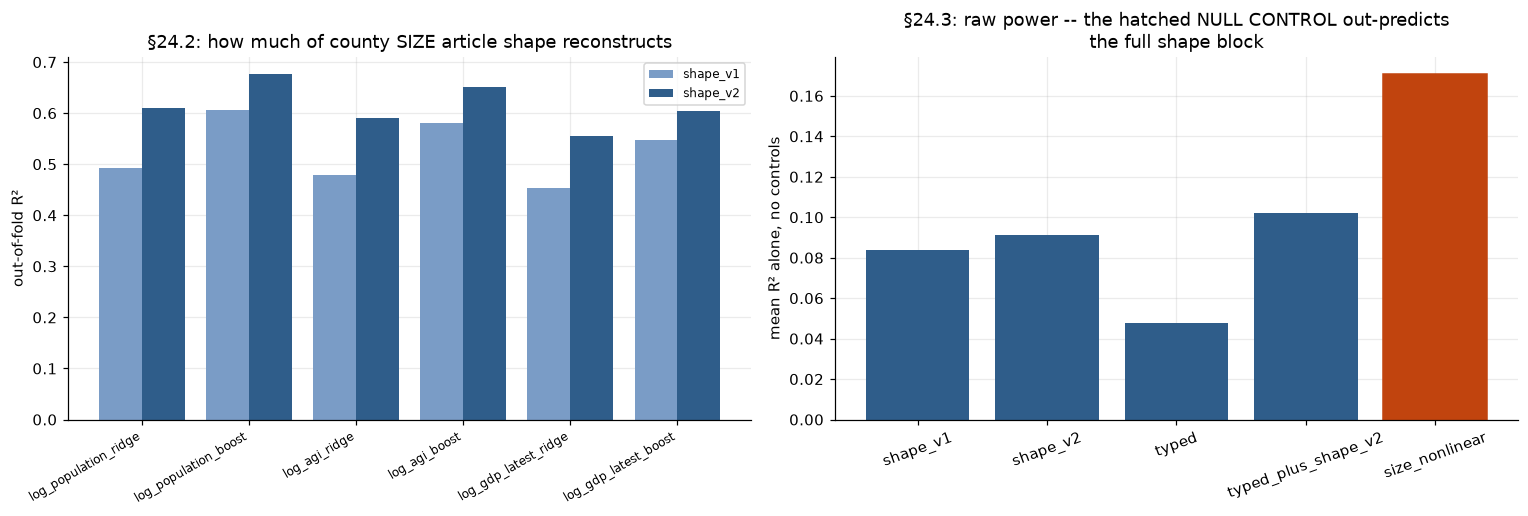

peak size recoverability: R² = 0.6760 -- the shape_v2 block (137 columns, boost) reconstructing log_population.
article shape encodes county size to that degree. Every lift in Parts four
and five is what remains AFTER a control has already removed size.

raw power, no controls: null control 0.1706 against the 137-column shape block's 0.0913.
9 reshapings of the baseline's own size columns out-predict article shape, with no controls on either.

shape_v2 (137 cols) vs the baseline: +0.00260, 21/28, p = 0.0013
shape_v2 vs shape_v1 (64 cols), the same paired protocol:      p = 0.4515
  ... and p = 0.4515 over the flexible baseline on all 28, p = 0.4245 on the undegraded 22.
73 new columns in four new families, and the test cannot tell them apart from round one's block.

both flexible denominators for every arm, because they disagree on 'typed':
  shape_v1               all-28: +0.00073 p=0.0281   undegraded-22: +0.00062 p=0.2099
  shape_v2               all-28: +0.00084 p=0.0048   undegrad

In [12]:
recovery = pd.DataFrame(shape_stats["size_recoverability"]).T
display(recovery.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
cols = list(recovery.columns)
x = np.arange(len(cols))
for offset, block, color in zip((-0.2, 0.2), recovery.index, ("#7a9cc6", "#2f5d8a")):
    axes[0].bar(x + offset, recovery.loc[block], 0.4, label=block, color=color)
axes[0].set_xticks(x)
axes[0].set_xticklabels(cols, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("out-of-fold R²")
axes[0].set_title("§24.2: how much of county SIZE article shape reconstructs")
axes[0].legend(fontsize=8)

alone = pd.Series({
    arm: shape_stats["arms"][f"{arm}_ridge"]["mean_r2_alone"]
    for arm in ("shape_v1", "shape_v2", "typed", "typed_plus_shape_v2", "size_nonlinear")
})
bars = axes[1].bar(alone.index, alone.values, color="#2f5d8a")
bars[-1].set_hatch("//")
bars[-1].set_color("#c1440e")
axes[1].set_ylabel("mean R² alone, no controls")
axes[1].set_title("§24.3: raw power -- the hatched NULL CONTROL out-predicts\n"
                  "the full shape block")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

peak = recovery.max().max()
block, cell = recovery.stack().idxmax()
measure, learner = cell.rsplit("_", 1)
print(f"peak size recoverability: R² = {peak:.4f} -- the {block} block "
      f"({shape_stats['n_shape_v2_features']} columns, {learner}) reconstructing "
      f"{measure}.")
print("article shape encodes county size to that degree. Every lift in Parts four")
print("and five is what remains AFTER a control has already removed size.")
print()
print(f"raw power, no controls: null control "
      f"{alone['size_nonlinear']:.4f} against the "
      f"{shape_stats['n_shape_v2_features']}-column shape block's "
      f"{alone['shape_v2']:.4f}.")
print(f"{struct_stats['n_size_nonlinear_features']} reshapings of the baseline's own "
      "size columns out-predict article shape, with no controls on either.")
print()
v2, v1 = shape_stats["arms"]["shape_v2_ridge"], shape_stats["arms"]["shape_v1_ridge"]
print(f"shape_v2 ({shape_stats['n_shape_v2_features']} cols) vs the baseline: "
      f"{v2['linear']['mean_lift']:+.5f}, "
      f"{v2['linear']['vs_baseline']['n_wins']}/{shape_stats['n_targets']}, "
      f"p = {v2['linear']['vs_baseline']['wilcoxon_p']:.4f}")
print(f"shape_v2 vs shape_v1 ({shape_stats['n_shape_v1_features']} cols), the same "
      f"paired protocol:      p = {v2['linear']['vs_arm']['wilcoxon_p']:.4f}")
print(f"  ... and p = {v2['flexible']['vs_arm']['wilcoxon_p']:.4f} over the flexible "
      f"baseline on all {shape_stats['n_targets']}, "
      f"p = {v2['flexible']['undegraded']['vs_arm']['wilcoxon_p']:.4f} on the "
      f"undegraded {v2['flexible']['undegraded']['n_targets']}.")
print(f"{shape_stats['n_shape_profile_features']} new columns in four new families, and "
      "the test cannot tell them apart from round one's block.")
print()
print("both flexible denominators for every arm, because they disagree on 'typed':")
for arm in ("shape_v1", "shape_v2", "typed", "typed_plus_shape_v2", "size_nonlinear"):
    flex = shape_stats["arms"][f"{arm}_ridge"]["flexible"]
    undeg = flex["undegraded"]
    print(f"  {arm:22} all-{shape_stats['n_targets']}: {flex['mean_lift']:+.5f} "
          f"p={flex['vs_baseline']['wilcoxon_p']:.4f}   "
          f"undegraded-{undeg['n_targets']}: {undeg['mean_lift']:+.5f} "
          f"p={undeg['vs_baseline']['wilcoxon_p']:.4f}")

## Part six — the ledger

Every headline Source A ever produced, with the control that was missing when it
was produced, and what was left afterward. Assembled from the same artifacts the
cells above read, so this table cannot drift from them.

In [13]:
ledger = pd.DataFrame([
    {
        "§": "13-14",
        "claim as first measured": f"{struct_stats['n_typed_features']} typed columns "
                                   "lift over size + state",
        "as measured": marg_stats["variants"]["extracted_sections"]["mean_lift_thin"],
        "control later added": "the other five pillars (§17)",
        "after the control": marg_stats["variants"]["extracted_sections"]["mean_lift_crowded"],
        "share left": marg_stats["variants"]["extracted_sections"]["share_retained"],
        "still significant?": "yes, p = "
                              f"{marg_stats['variants']['extracted_sections']['wilcoxon_p_crowded']:.3f}",
    },
    {
        "§": "22",
        "claim as first measured": "selected embedding arm, decision basket",
        "as measured": by_rep[SELECTED]["decision_basket_mean_contribution"],
        "control later added": "two lat/lon columns (§22.2)",
        "after the control": by_rep[SELECTED]["decision_basket_mean_contribution_geo"],
        "share left": (by_rep[SELECTED]["decision_basket_mean_contribution_geo"]
                       / by_rep[SELECTED]["decision_basket_mean_contribution"]),
        "still significant?": "no -- win rate falls to about half the basket",
    },
    {
        "§": "22",
        "claim as first measured": "the shipped block's transformed variant, "
                                   "same basket",
        "as measured": by_rep[COMPARATOR]["decision_basket_mean_contribution"],
        "control later added": "two lat/lon columns (§22.2)",
        "after the control": by_rep[COMPARATOR]["decision_basket_mean_contribution_geo"],
        "share left": (by_rep[COMPARATOR]["decision_basket_mean_contribution_geo"]
                       / by_rep[COMPARATOR]["decision_basket_mean_contribution"]),
        "still significant?": "no -- substantially negative",
    },
    {
        "§": "23",
        "claim as first measured": f"article shape, {struct_stats['n_structure_features']} "
                                   "columns, over a LINEAR-in-logs size baseline",
        "as measured": struct_stats["arms"]["structure"]["mean_lift"],
        "control later added": "curvature in the same size columns (§23.4)",
        "after the control": struct_stats["arms_flexible"]["structure"]["mean_lift"],
        "share left": struct_stats["flexible_retention"]["structure"],
        "still significant?": "all-28 yes (p = "
                              f"{struct_stats['arms_flexible']['structure']['wilcoxon_p']:.4f}), "
                              "undegraded-22 no (p = "
                              f"{struct_stats['arms_flexible_undegraded']['structure']['wilcoxon_p']:.4f})",
    },
    {
        "§": "23",
        "claim as first measured": "NULL CONTROL, information-free, through the "
                                   "identical protocol",
        "as measured": struct_stats["arms"][NULL]["mean_lift"],
        "control later added": "the same curvature control (§23.3)",
        "after the control": struct_stats["arms_flexible"][NULL]["mean_lift"],
        "share left": struct_stats["flexible_retention"][NULL],
        "still significant?": "no -- absorbed to zero, which is the construction check",
    },
    {
        "§": "24",
        "claim as first measured": f"{shape_stats['n_shape_v2_features']}-column shape "
                                   "block over the linear baseline",
        "as measured": shape_stats["arms"]["shape_v2_ridge"]["linear"]["mean_lift"],
        "control later added": "the same curvature control (§24.5)",
        "after the control": shape_stats["arms"]["shape_v2_ridge"]["flexible"]["mean_lift"],
        "share left": (shape_stats["arms"]["shape_v2_ridge"]["flexible"]["mean_lift"]
                       / shape_stats["arms"]["shape_v2_ridge"]["linear"]["mean_lift"]),
        "still significant?": "yes on both denominators, but it does not beat the "
                              "64-column block it extends (p = "
                              f"{shape_stats['arms']['shape_v2_ridge']['linear']['vs_arm']['wilcoxon_p']:.4f})",
    },
])
# A "share left" is only meaningful while the sign holds; where the control
# drove the arm below zero, a percentage of the original would read as a large
# negative number and mean nothing.
ledger["share left"] = [
    f"{share:.0%}" if after >= 0 else "sign flipped"
    for share, after in zip(ledger["share left"], ledger["after the control"])
]
ledger["as measured"] = ledger["as measured"].map("{:+.6f}".format)
ledger["after the control"] = ledger["after the control"].map("{:+.6f}".format)
display(ledger)

print("The pattern is the finding. Four rounds, four controls that cost almost")
print("nothing to add, and in every case the headline shrank or inverted.")
print()
print(f"§24.2 is the sharpest version of it: article shape reconstructs {measure} at")
print(f"out-of-fold R² = {peak:.3f} on its own. Whatever a shape lift is measuring,")
print("the block would have rebuilt most of county size unaided.")

,§,claim as first measured,as measured,control later added,after the control,share left,still significant?
0,13-14,29 typed columns lift over size + state,+0.003642,the other five pillars (§17),+0.001049,29%,"yes, p = 0.010"
1,22,"selected embedding arm, decision basket",+0.016397,two lat/lon columns (§22.2),+0.000607,4%,no -- win rate falls to about half the basket
2,22,"the shipped block's transformed variant, same ...",+0.001654,two lat/lon columns (§22.2),-0.014137,sign flipped,no -- substantially negative
3,23,"article shape, 64 columns, over a LINEAR-in-lo...",+0.002686,curvature in the same size columns (§23.4),+0.000734,27%,"all-28 yes (p = 0.0281), undegraded-22 no (p =..."
4,23,"NULL CONTROL, information-free, through the id...",+0.017478,the same curvature control (§23.3),+0.000000,0%,"no -- absorbed to zero, which is the construct..."
5,24,137-column shape block over the linear baseline,+0.002597,the same curvature control (§24.5),+0.000841,32%,"yes on both denominators, but it does not beat..."


The pattern is the finding. Four rounds, four controls that cost almost
nothing to add, and in every case the headline shrank or inverted.

§24.2 is the sharpest version of it: article shape reconstructs log_population at
out-of-fold R² = 0.676 on its own. Whatever a shape lift is measuring,
the block would have rebuilt most of county size unaided.


## Where Source A actually stands

**What ships.** Twenty-nine typed columns, in `data/source_a_text_features.parquet`,
flowing into `pillar_matrix.build_matrix` as Source A's block. Two columns are
withheld as diagnostics rather than predictors: the USDA-echo flag (a detector
for circularity must not itself be a predictor) and the body-section count (a
size proxy). Absence is `False`, not null, with `founding_year` the single
documented exception.

**Why it ships.** §17, and only §17: against a baseline holding county size,
state and every other pillar, the typed block retains a small but statistically
real contribution on a well-powered test, and its surviving value is
*semantically coherent* — it survives on the targets whose meaning its lexicons
match and dies on the ones a federal agency already measures directly. That
coherence is the strongest evidence in the line that the extraction does
something real. Plan around the crowded-baseline figure, never the
size-plus-state one, and adjust for which pillars a consuming model's targets
resemble — retention spans two orders of magnitude across pillars and the basket
is 71% its worst-retaining block.

**What is not settled, and cannot be from inside this repo.** Every target in
every basket here is either another pillar's feature or a public ACS proxy. The
consuming model's real target is external, and a source can be redundant for
predicting a sibling pillar's column and still carry independent information
about an external outcome. Two conventions inherited from the pillar-versus-pillar
sweeps — ablating the metro-attachment flag as a restatement of another pillar,
and penalizing a source precisely for agreeing with pillars it ships alongside —
are correct for assembling a non-redundant feature store and wrong for
predicting an external outcome. Any external-target harness has to revisit both
rather than inherit them.

**Claims this notebook will not make, because the register forbids them.**
That article shape knows something county size does not, in any phrasing —
§24.2 does not merely leave that unlicensed, it contradicts it. That typed
extraction beats the embedding — it ties, on every head-to-head run. That Source
A contributes its size-plus-state figure to a fused model — the retention share
printed in Part two is what that overstates by. That the selected embedding arm's advantage survives the
geography control as real content value — what survives is its *margin over the
typed comparator*, which is a mathematical property of a paired test rather than
new evidence. And no figure from §22 without naming its basket, or from §23–§24
without both flexible denominators.

**Where to go next.**

| for | read |
|---|---|
| the full register, §1–§24, with allowed/forbidden wording per round | `source-a-findings.md` |
| §13–§18 in depth — extraction, tiers, the crowded baseline | `source_a_extraction_round.ipynb` |
| §23 in depth — the structural block and the null-arm calibration | `source_a_structure_round.ipynb` |
| §24 in depth — the shape profile, size recoverability, the width-matched boost floor | `source_a_shape_profile_round.ipynb` |

**Two open questions the rounds named and did not take.** Accommodation & Food
Services LQ is the one target where article shape clearly holds its lift under
the flexible size control, and a mechanism exists — tourism and lodging show up
in article structure. And since the shape block reconstructs county size to
two-thirds R², the honest version of "what does article shape know" is to
residualize the block against *recovered* size before scoring it, rather than
residualizing the target against *measured* size after. Both are new
experiments, not reanalyses.